Prueba

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from keras.models import Sequential
from keras.layers import Dense, Dropout, GRU, InputLayer, Flatten, LSTM
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
import random


LEER DATASET

In [2]:
import pandas as pd

datosMLP = pd.read_csv("C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\1pasos_mlp_consumption.csv")
datosLSTM = pd.read_csv("C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\1pasos_lstm_consumption.csv")
datosGRU = pd.read_csv("C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\datosNarmax\\1pasos_gru_consumption.csv")

datosMLP['date'] = pd.to_datetime(datosMLP['date'])
datosLSTM['date'] = pd.to_datetime(datosLSTM['date'])
datosGRU['date'] = pd.to_datetime(datosGRU['date'])

# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)
datosLSTM.set_index('date', inplace=True)
datosGRU.set_index('date', inplace=True)


In [3]:
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe MLP input es un tipo de dato: ", datosMLP.index.dtype)
print("El index del dataframe LSTM input es un tipo de dato: ", datosLSTM.index.dtype)
print("El index del dataframe GRU input es un tipo de dato: ", datosGRU.index.dtype)


El index del dataframe MLP input es un tipo de dato:  datetime64[ns]
El index del dataframe LSTM input es un tipo de dato:  datetime64[ns]
El index del dataframe GRU input es un tipo de dato:  datetime64[ns]


Se establece el formato de datos de entrada para redes GRU y LSTM, es decir [observaciones, retardos, caracteristicas]

In [4]:
futuros = 1
pasados  = 12

In [5]:
datosMLPX = []
datosMLPY = []
for i in range(pasados, len(datosMLP) - futuros + 1):
  datosMLPX.append(datosMLP.iloc[i-pasados:i, 0:datosMLP.shape[1]])
  datosMLPY.append(datosMLP.iloc[i+futuros-1:i+futuros, 1])


In [6]:
datosLSTMX = []
datosLSTMY = []
for i in range(pasados, len(datosLSTM) - futuros + 1):
  datosLSTMX.append(datosLSTM.iloc[i-pasados:i, 0:datosLSTM.shape[1]])
  datosLSTMY.append(datosLSTM.iloc[i+futuros-1:i+futuros, 1])

In [7]:
datosGRUX = []
datosGRUY = []
for i in range(pasados, len(datosGRU) - futuros + 1):
  datosGRUX.append(datosGRU.iloc[i-pasados:i, 0:datosGRU.shape[1]])
  datosGRUY.append(datosGRU.iloc[i+futuros-1:i+futuros, 1])

In [8]:
# Convertir las listas en arrays numpy
datosMLPX = np.array(datosMLPX)
datosMLPY = np.array(datosMLPY)

# Ver las dimensiones (shape) de los arrays
print("Dimensiones de MLP X:", datosMLPX.shape)  
print("Dimensiones de MLP Y:", datosMLPY.shape)  

Dimensiones de MLP X: (52404, 12, 6)
Dimensiones de MLP Y: (52404, 1)


In [9]:
# Convertir las listas en arrays numpy
datosLSTMX = np.array(datosLSTMX)
datosLSTMY = np.array(datosLSTMY)

# Ver las dimensiones (shape) de los arrays
print("Dimensiones de LSTM X:", datosLSTMX.shape)  
print("Dimensiones de LSTM Y:", datosLSTMY.shape)  

Dimensiones de LSTM X: (52404, 12, 6)
Dimensiones de LSTM Y: (52404, 1)


In [10]:
# Convertir las listas en arrays numpy
datosGRUX = np.array(datosGRUX)
datosGRUY = np.array(datosGRUY)

# Ver las dimensiones (shape) de los arrays
print("Dimensiones de GRU X:", datosGRUX.shape)  
print("Dimensiones de GRU Y:", datosGRUY.shape)  

Dimensiones de GRU X: (52404, 12, 6)
Dimensiones de GRU Y: (52404, 1)


In [11]:
inputs = datosMLPX.shape[1] * datosMLPX.shape[2]
datosMLPX = datosMLPX.reshape(datosMLPX.shape[0], inputs)

Se dividen nuevamente los conjuntos de datos

In [12]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainMLPX, testMLPX = train_test_split(datosMLPX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testMLPX, valMLPX = train_test_split(testMLPX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainMLPX son: ", trainMLPX.shape)
print("Las dimensiones de testMLPX son: ", testMLPX.shape)
print("Las dimensiones de valMLPX son: ", valMLPX.shape)


Las dimensiones de trainMLPX son:  (36682, 72)
Las dimensiones de testMLPX son:  (10533, 72)
Las dimensiones de valMLPX son:  (5189, 72)


In [13]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainLSTMX, testLSTMX = train_test_split(datosLSTMX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testLSTMX, valLSTMX = train_test_split(testLSTMX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainLSTMX son: ", trainLSTMX.shape)
print("Las dimensiones de testLSTMX son: ", testLSTMX.shape)
print("Las dimensiones de valLSTMX son: ", valLSTMX.shape)

Las dimensiones de trainLSTMX son:  (36682, 12, 6)
Las dimensiones de testLSTMX son:  (10533, 12, 6)
Las dimensiones de valLSTMX son:  (5189, 12, 6)


In [14]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainGRUX, testGRUX = train_test_split(datosGRUX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testGRUX, valGRUX = train_test_split(testGRUX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainGRUX son: ", trainGRUX.shape)
print("Las dimensiones de testGRUX son: ", testGRUX.shape)
print("Las dimensiones de valGRUX son: ", valGRUX.shape)

Las dimensiones de trainGRUX son:  (36682, 12, 6)
Las dimensiones de testGRUX son:  (10533, 12, 6)
Las dimensiones de valGRUX son:  (5189, 12, 6)


In [15]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainY, testY = train_test_split(datosMLPY, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testY, valY = train_test_split(testY, test_size=0.33, shuffle=False)

print("Las dimensiones de trainY son: ", trainY.shape)
print("Las dimensiones de testY son: ", testY.shape)
print("Las dimensiones de valY son: ", valY.shape)

Las dimensiones de trainY son:  (36682, 1)
Las dimensiones de testY son:  (10533, 1)
Las dimensiones de valY son:  (5189, 1)


Se crean métricas para medir desempeño

In [16]:
import tensorflow.keras.backend as K

def smape(y_true, y_pred):
    """
    Define la función SMAPE (Error Porcentual Absoluto Medio Simétrico).
    """
    summ = K.abs(y_true) + K.abs(y_pred)
    smape_val = K.abs(y_pred - y_true) / summ * 2.0
    return K.mean(smape_val, axis=-1)

def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

def ia(y_true, y_pred):
    numerator = K.sum(K.abs(y_true - y_pred))
    denominator = K.sum(K.abs(y_true - K.mean(y_true)) + K.abs(y_pred - K.mean(y_true)))
    return 1 - (numerator / denominator)

Se define el index del conjunto de validación para utilizarlo posteriormente para graficar.

In [17]:
# Fecha y hora de término del conjunto de datos de prueba
end_date = datosMLP.index[-1]
n_observations = valY.shape[0]  # Cambia esto al número de observaciones en tu conjunto de prueba

# Calcular la fecha y hora de inicio
start_date = end_date - timedelta(minutes=10 * (n_observations - 1))

# Crear la serie de fechas y horas
val_date = pd.date_range(start=start_date, end=end_date, freq='10T')

val_date

C:\Users\wamt1\AppData\Local\Temp\ipykernel_15860\572609118.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  val_date = pd.date_range(start=start_date, end=end_date, freq='10T')


DatetimeIndex(['2017-11-24 23:10:00', '2017-11-24 23:20:00',
               '2017-11-24 23:30:00', '2017-11-24 23:40:00',
               '2017-11-24 23:50:00', '2017-11-25 00:00:00',
               '2017-11-25 00:10:00', '2017-11-25 00:20:00',
               '2017-11-25 00:30:00', '2017-11-25 00:40:00',
               ...
               '2017-12-30 22:20:00', '2017-12-30 22:30:00',
               '2017-12-30 22:40:00', '2017-12-30 22:50:00',
               '2017-12-30 23:00:00', '2017-12-30 23:10:00',
               '2017-12-30 23:20:00', '2017-12-30 23:30:00',
               '2017-12-30 23:40:00', '2017-12-30 23:50:00'],
              dtype='datetime64[ns]', length=5189, freq='10min')

Se guardan los índices de las observaciones a utilizar para predecir

In [18]:
indices = []
for i in range(pasados, len(datosMLP) - futuros + 1):
  indices.append(datosMLP.index[i+futuros-2])

# Modelos


## MLP

In [19]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [20]:
modelMLP = Sequential()
modelMLP.add(InputLayer(input_shape=(testMLPX.shape[1],)))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))

modelMLP.add(Dense(units=128, activation="linear"))
modelMLP.add(Dropout(0.0))


modelMLP.add(Dense(1))

opt = Adam(learning_rate=0.00027101707182655693)

modelMLP.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelMLP.summary()








c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,009 (230.50 KB)

 Trainable params: 59,009 (230.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)


early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyMLP = modelMLP.fit(testMLPX, testY, epochs=128,
                        validation_split=0.3,
                        verbose = 2, batch_size=16, callbacks=[early_stopping])

prediccionMLP = modelMLP.predict(valMLPX)


Epoch 1/128
461/461 - 4s - 10ms/step - ia: 0.9350 - loss: 0.0223 - mae: 0.0917 - rmse: 0.1163 - smape: 0.2480 - val_ia: 0.8116 - val_loss: 0.0041 - val_mae: 0.0436 - val_rmse: 0.0565 - val_smape: 0.1239
Epoch 2/128
461/461 - 1s - 2ms/step - ia: 0.9592 - loss: 0.0057 - mae: 0.0573 - rmse: 0.0721 - smape: 0.1715 - val_ia: 0.7875 - val_loss: 0.0040 - val_mae: 0.0457 - val_rmse: 0.0581 - val_smape: 0.1244
Epoch 3/128
461/461 - 1s - 3ms/step - ia: 0.9633 - loss: 0.0047 - mae: 0.0515 - rmse: 0.0653 - smape: 0.1604 - val_ia: 0.7723 - val_loss: 0.0044 - val_mae: 0.0498 - val_rmse: 0.0619 - val_smape: 0.1361
Epoch 4/128
461/461 - 1s - 3ms/step - ia: 0.9641 - loss: 0.0046 - mae: 0.0503 - rmse: 0.0639 - smape: 0.1568 - val_ia: 0.7743 - val_loss: 0.0046 - val_mae: 0.0512 - val_rmse: 0.0635 - val_smape: 0.1518
Epoch 5/128
461/461 - 3s - 6ms/step - ia: 0.9631 - loss: 0.0047 - mae: 0.0518 - rmse: 0.0655 - smape: 0.1597 - val_ia: 0.7867 - val_loss: 0.0040 - val_mae: 0.0466 - val_rmse: 0.0589 - val_sma

In [22]:
metricasMLP = modelMLP.evaluate(valMLPX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasMLP}")

163/163 - 0s - 2ms/step - ia: 0.9178 - loss: 0.0022 - mae: 0.0350 - rmse: 0.0453 - smape: 0.1161
Métricas en el conjunto de validación: [0.0021869626361876726, 0.03497084975242615, 0.11608248949050903, 0.04528080299496651, 0.9177740216255188]


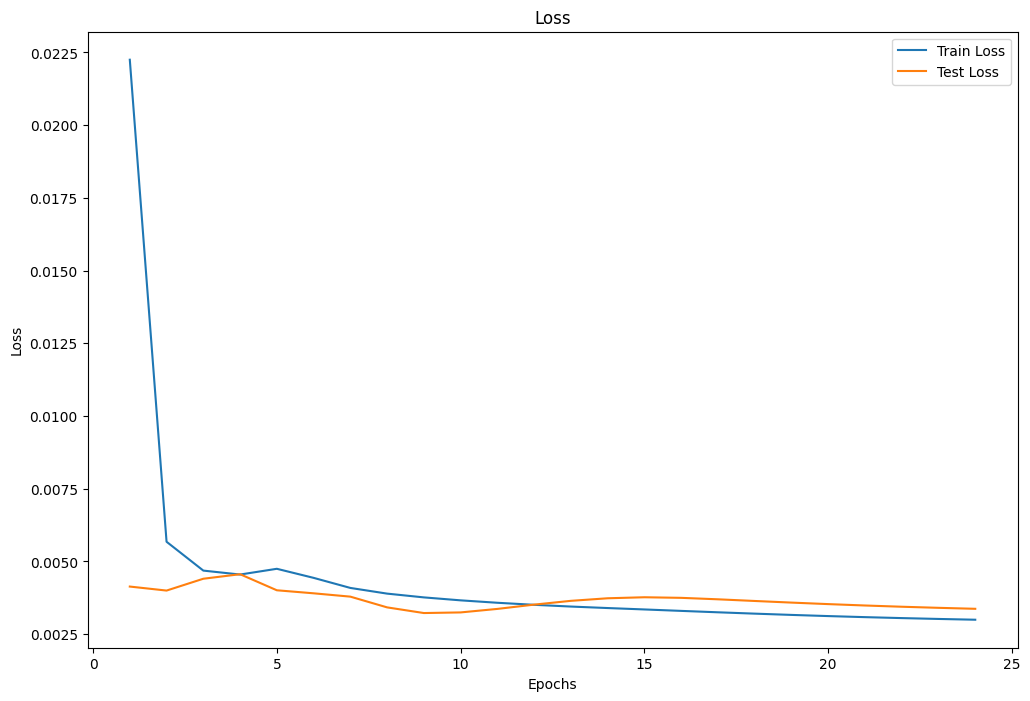

In [23]:
historyMLP = historyMLP.history

ejeXMLP = range(1, len(historyMLP['loss']) + 1)

plt.figure(figsize=(12, 8))
plt.plot(ejeXMLP, historyMLP['loss'], label='Train Loss')
plt.plot(ejeXMLP, historyMLP['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyMLP['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyMLP['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.0029981955885887146
Último valor de Test Loss: 0.0033735570032149553


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionMLP.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfMLP = df
fig.show()

In [26]:
dfMLP.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\evaluacionNarmax\\1pasos_mlp_consumption.csv', index=True)

In [27]:
modelMLP.save('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\modelosEntranadosNarmax\\1pasos_mlp_consumption.h5')

## LSTM

In [28]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [29]:
modelLSTM = Sequential()
modelLSTM.add(InputLayer(input_shape=(testLSTMX.shape[1], testLSTMX.shape[2])))

modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=True))
modelLSTM.add(Dropout(0.0))


modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=True))
modelLSTM.add(Dropout(0.0))


modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=True))
modelLSTM.add(Dropout(0.0))

modelLSTM.add(LSTM(units=128, activation="linear", return_sequences=False))
modelLSTM.add(Dropout(0.0))

modelLSTM.add(Dense(1))


opt = Adam(learning_rate=0.00027101707182655693)
modelLSTM.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelLSTM.summary()



c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning:

Argument `input_shape` is deprecated. Use `shape` instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 464,001 (1.77 MB)

 Trainable params: 464,001 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)


early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyLSTM = modelLSTM.fit(testLSTMX, testY, epochs=128,
                        validation_split=0.3,
                        verbose = 2, batch_size=16, callbacks=[early_stopping])

prediccionLSTM = modelLSTM.predict(valLSTMX)

Epoch 1/128
461/461 - 24s - 52ms/step - ia: 0.8329 - loss: 0.1047 - mae: 0.2219 - rmse: 0.2877 - smape: 0.4976 - val_ia: 0.5130 - val_loss: 0.0426 - val_mae: 0.1553 - val_rmse: 0.1795 - val_smape: 0.3925
Epoch 2/128
461/461 - 9s - 19ms/step - ia: 0.9295 - loss: 0.0197 - mae: 0.0987 - rmse: 0.1330 - smape: 0.2677 - val_ia: 0.6646 - val_loss: 0.0167 - val_mae: 0.0874 - val_rmse: 0.1071 - val_smape: 0.2196
Epoch 3/128
461/461 - 9s - 20ms/step - ia: 0.9525 - loss: 0.0086 - mae: 0.0664 - rmse: 0.0880 - smape: 0.2004 - val_ia: 0.7116 - val_loss: 0.0106 - val_mae: 0.0705 - val_rmse: 0.0865 - val_smape: 0.1905
Epoch 4/128
461/461 - 11s - 23ms/step - ia: 0.9608 - loss: 0.0058 - mae: 0.0549 - rmse: 0.0726 - smape: 0.1686 - val_ia: 0.7489 - val_loss: 0.0081 - val_mae: 0.0597 - val_rmse: 0.0747 - val_smape: 0.1703
Epoch 5/128
461/461 - 11s - 23ms/step - ia: 0.9646 - loss: 0.0047 - mae: 0.0496 - rmse: 0.0653 - smape: 0.1566 - val_ia: 0.7681 - val_loss: 0.0067 - val_mae: 0.0540 - val_rmse: 0.0682 - 

In [31]:
metricasLSTM = modelLSTM.evaluate(valLSTMX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasLSTM}")

163/163 - 3s - 16ms/step - ia: 0.9180 - loss: 0.0018 - mae: 0.0317 - rmse: 0.0406 - smape: 0.0991
Métricas en el conjunto de validación: [0.001798965036869049, 0.031662724912166595, 0.09908877313137054, 0.04059069603681564, 0.9179763197898865]


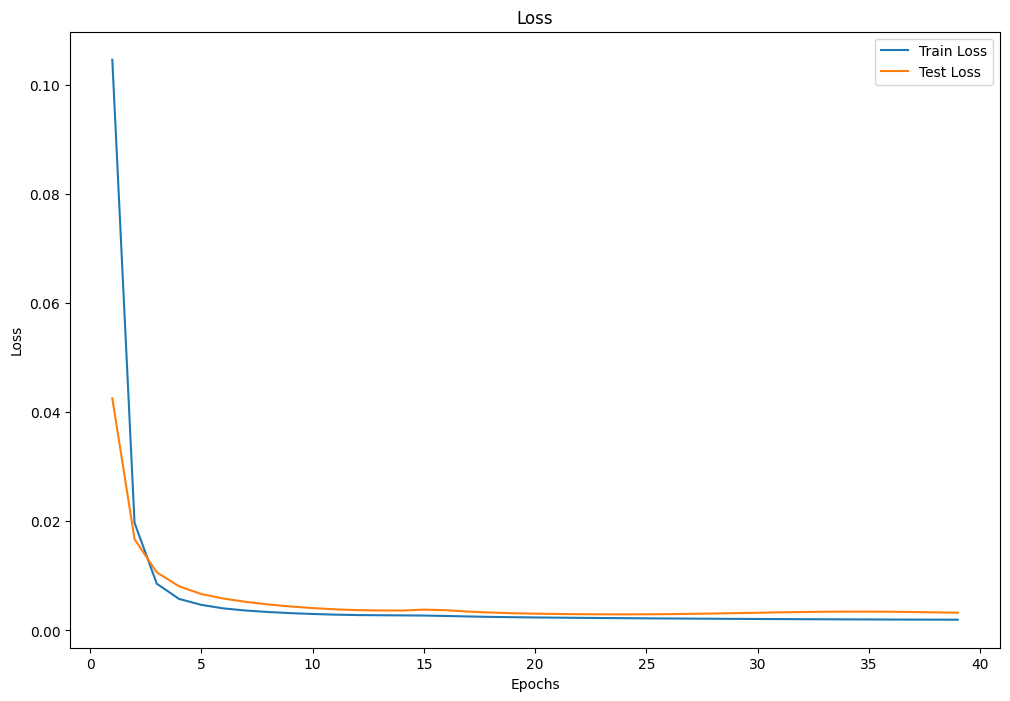

In [32]:
historyLSTM = historyLSTM.history

ejeXLSTM = range(1, len(historyLSTM['loss']) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXLSTM, historyLSTM['loss'], label='Train Loss')
plt.plot(ejeXLSTM, historyLSTM['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [33]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyLSTM['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyLSTM['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.0019575227051973343
Último valor de Test Loss: 0.0032354090362787247


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionLSTM.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfLSTM = df
fig.show()


In [35]:
dfLSTM.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\evaluacionNarmax\\1pasos_lstm_consumption.csv', index=True)

In [46]:
modelLSTM.save('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\modelosEntranadosNarmax\\1pasos_lstm_consumption.h5')

## GRU

In [37]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [38]:
modelGRU = Sequential()
modelGRU.add(InputLayer(input_shape=(testGRUX.shape[1], testGRUX.shape[2])))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=True))
modelGRU.add(Dropout(0.0))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=True))
modelGRU.add(Dropout(0.0))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=True))
modelGRU.add(Dropout(0.0))

modelGRU.add(GRU(units=128, activation="linear", return_sequences=False))
modelGRU.add(Dropout(0.0))

modelGRU.add(Dense(1))


opt = Adam(learning_rate=0.00027101707182655693)
modelGRU.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelGRU.summary()




c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning:

Argument `input_shape` is deprecated. Use `shape` instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 128)        │        52,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 12, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 12, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 349,569 (1.33 MB)

 Trainable params: 349,569 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)

early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyGRU = modelGRU.fit(testGRUX, testY, epochs=128,
                        validation_split=0.3,
                        verbose = 2, batch_size=16, callbacks=[early_stopping])

prediccionGRU = modelGRU.predict(valGRUX)

Epoch 1/128
461/461 - 23s - 50ms/step - ia: 0.9263 - loss: 0.0315 - mae: 0.1002 - rmse: 0.1336 - smape: 0.2554 - val_ia: 0.7962 - val_loss: 0.0049 - val_mae: 0.0471 - val_rmse: 0.0605 - val_smape: 0.1323
Epoch 2/128
461/461 - 10s - 23ms/step - ia: 0.9675 - loss: 0.0039 - mae: 0.0455 - rmse: 0.0599 - smape: 0.1423 - val_ia: 0.8174 - val_loss: 0.0036 - val_mae: 0.0403 - val_rmse: 0.0527 - val_smape: 0.1210
Epoch 3/128
461/461 - 21s - 46ms/step - ia: 0.9702 - loss: 0.0033 - mae: 0.0419 - rmse: 0.0547 - smape: 0.1344 - val_ia: 0.8252 - val_loss: 0.0033 - val_mae: 0.0375 - val_rmse: 0.0498 - val_smape: 0.1104
Epoch 4/128
461/461 - 12s - 25ms/step - ia: 0.9710 - loss: 0.0031 - mae: 0.0407 - rmse: 0.0529 - smape: 0.1334 - val_ia: 0.8321 - val_loss: 0.0033 - val_mae: 0.0369 - val_rmse: 0.0492 - val_smape: 0.1057
Epoch 5/128
461/461 - 13s - 27ms/step - ia: 0.9711 - loss: 0.0030 - mae: 0.0406 - rmse: 0.0524 - smape: 0.1350 - val_ia: 0.8230 - val_loss: 0.0035 - val_mae: 0.0390 - val_rmse: 0.0512 

In [40]:
metricasGRU = modelGRU.evaluate(valGRUX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasGRU}")

163/163 - 2s - 10ms/step - ia: 0.9277 - loss: 0.0016 - mae: 0.0289 - rmse: 0.0378 - smape: 0.0974
Métricas en el conjunto de validación: [0.001561834942549467, 0.028913749381899834, 0.09743764251470566, 0.03780882805585861, 0.9277119040489197]


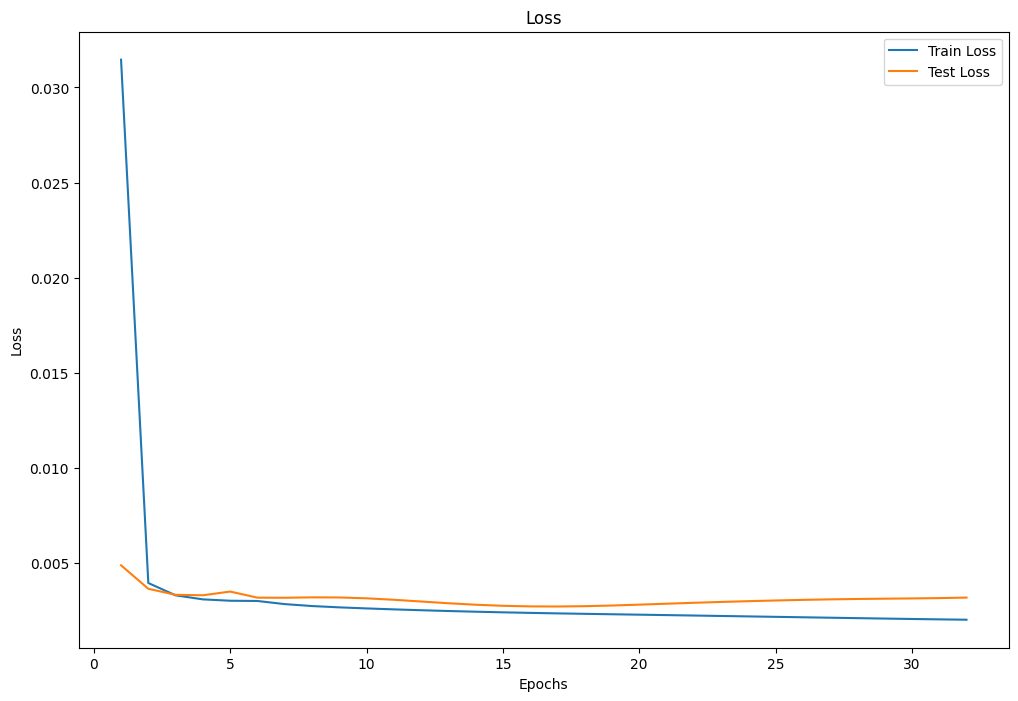

In [41]:
historyGRU = historyGRU.history

ejeXGRU = range(1, len(historyGRU['loss']) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXGRU, historyGRU['loss'], label='Train Loss')
plt.plot(ejeXGRU, historyGRU['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [42]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyGRU['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyGRU['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.0020087379962205887
Último valor de Test Loss: 0.003172493539750576


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionGRU.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfGRU = df
fig.show()

In [44]:
dfGRU.to_csv('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\evaluacionNarmax\\1pasos_gru_consumption.csv', index=True)

In [47]:
modelGRU.save('C:\\Users\\wamt1\\OneDrive\\Escritorio\\computadorNuevo2\\modelosEntranadosNarmax\\1pasos_gru_consumption.h5')